In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

filename= "BTC_2019-02.txt"
exchange_names = {
    1: "Coinbase",
    2: "BitFinex",
    3: "BitStamp",
    4: "HitBTC",
    5: "Kraken",
}
df= pd.read_csv(
    filename,
    names= ["timestamp","price","volume","exchange"])
df['timestamp']= (df['timestamp'].str.replace(r":(\d{3})$",r".\1", regex=True))
df['timestamp']=pd.to_datetime(df['timestamp'], format="%Y-%m-%d %H:%M:%S.%f")
df=df.set_index("timestamp")
print(df.head())

                           price   volume  exchange
timestamp                                          
2019-02-01 00:00:00.000  3413.69  0.16100         3
2019-02-01 00:00:00.334  3503.80  0.06000         2
2019-02-01 00:00:00.363  3436.77  0.04348         4
2019-02-01 00:00:00.468  3503.80  0.10300         2
2019-02-01 00:00:00.496  3411.50  0.10000         1


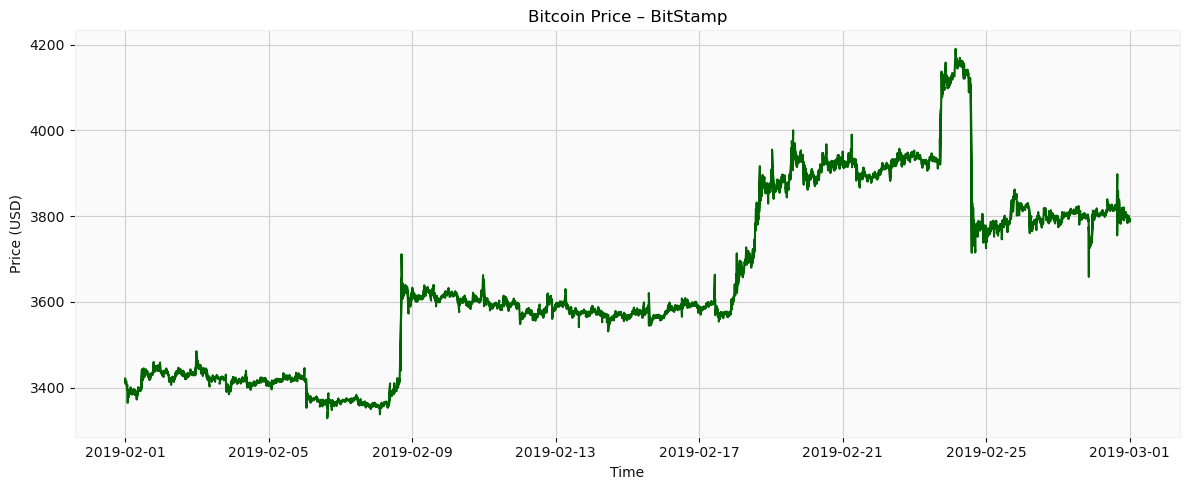

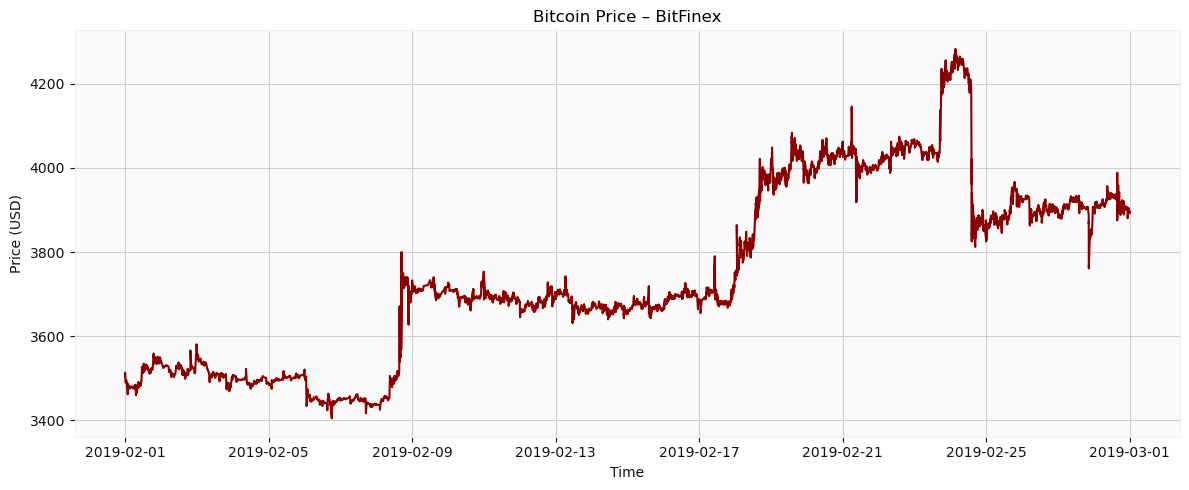

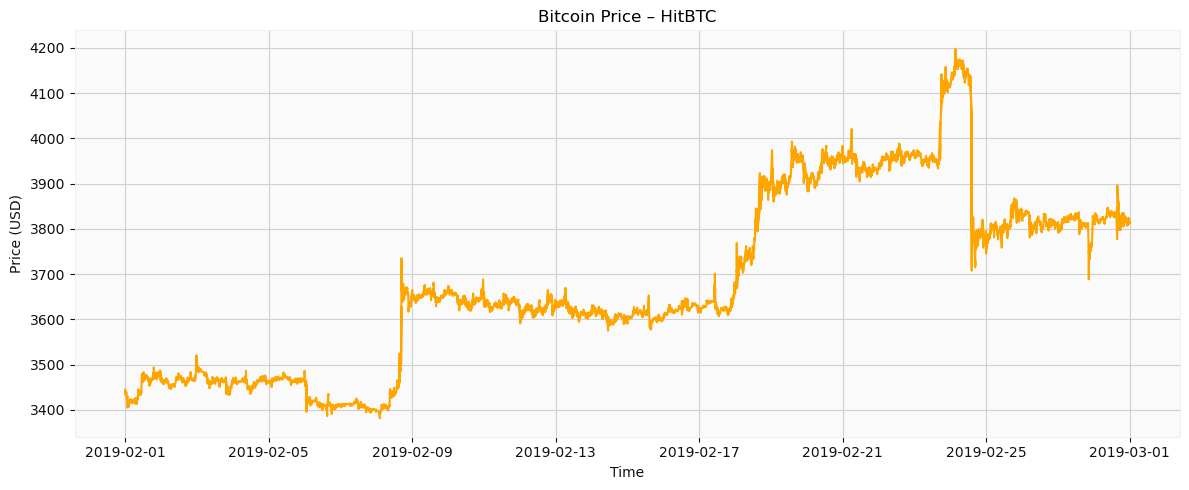

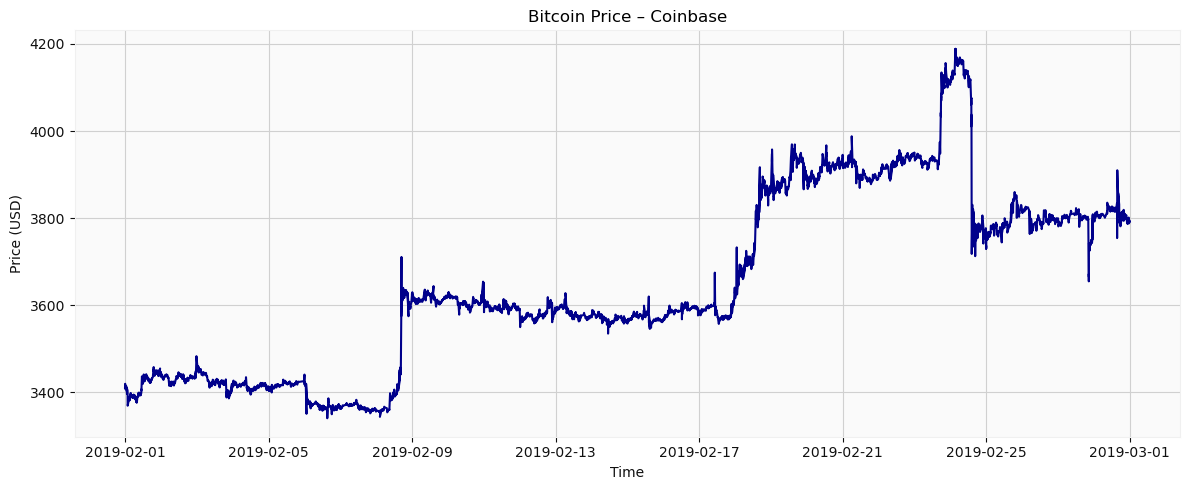

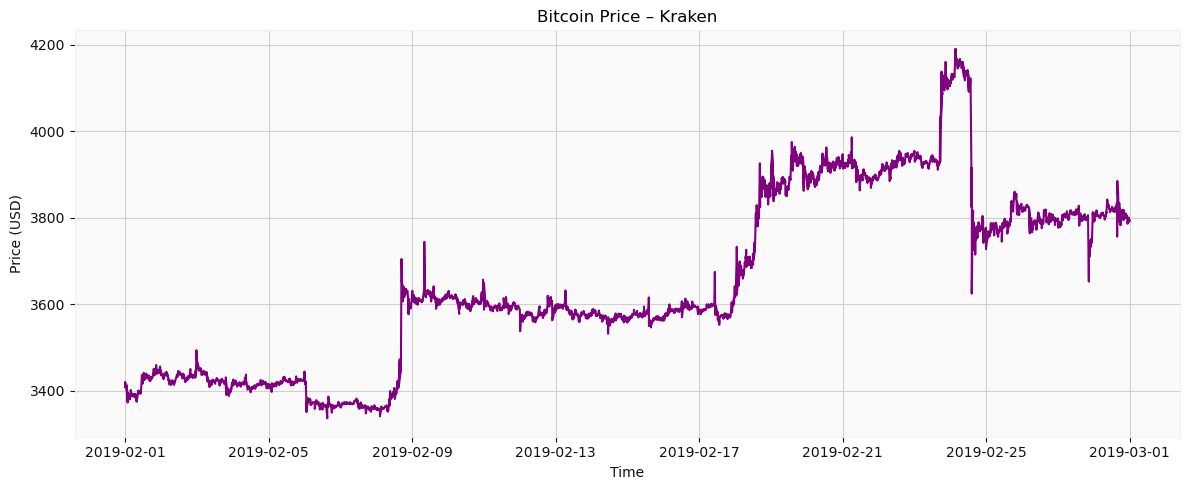

In [29]:
df['exchange']= df['exchange'].map(exchange_names)
df = df.dropna(subset=['exchange'])

import os
os.makedirs('figures', exist_ok=True)

color_map = {
    'Coinbase': 'darkblue',
    'BitStamp': 'darkgreen',
    'BitFinex': 'darkred',
    'Kraken': 'purple',
    'HitBTC': 'orange'}
for exch in df["exchange"].unique():
    df_exch = df[df["exchange"] == exch]
    plt.figure(figsize=(12,5))
    plt.plot(df_exch.index, df_exch["price"], color= color_map.get(exch, 'black'))
    plt.title(f"Bitcoin Price – {exch}")
    plt.xlabel("Time")
    plt.ylabel("Price (USD)")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f'figures/price_{exch}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

In [30]:
df['date']=df.index.date
daily_volume= df.groupby(['date','exchange'])['volume'].sum().unstack()
print(daily_volume.head())

exchange        BitFinex     BitStamp     Coinbase      HitBTC       Kraken
date                                                                       
2019-02-01  10040.641547  6659.139215  8806.417063  7130.93427  5790.437398
2019-02-02  10905.215875  3050.953452  3967.193625  3125.84995  2428.520682
2019-02-03   7874.536683  2813.868151  4605.859076  8718.96421  2316.065747
2019-02-04   5213.182238  3243.548329  6032.670108  5290.50972  2827.473788
2019-02-05   4590.399056  4045.600289  6385.185638  8376.31244  2734.489519


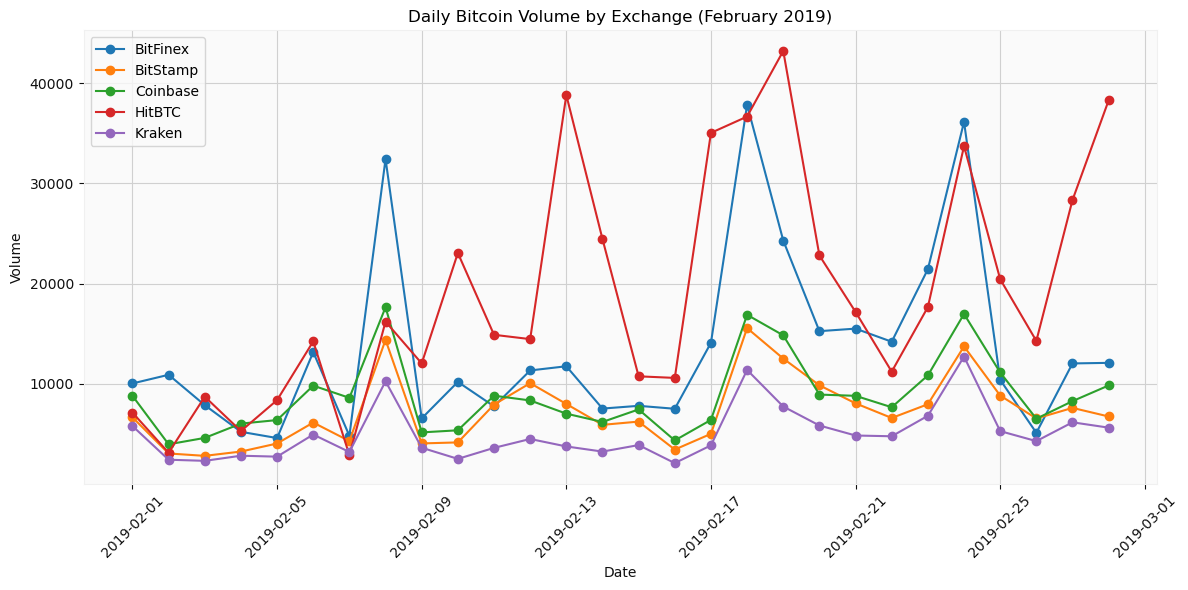

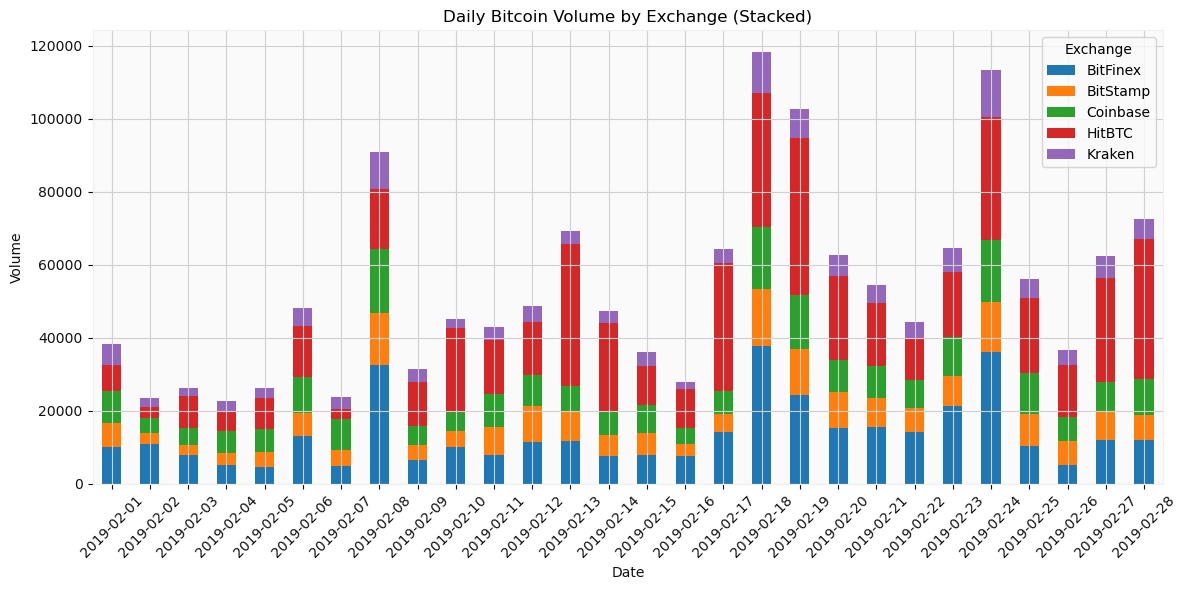

Most popular exchange by total volume: HitBTC


In [31]:
plt.figure(figsize=(12,6))

for exch in daily_volume.columns:
    plt.plot(daily_volume.index, daily_volume[exch], marker='o', label=exch)

plt.title("Daily Bitcoin Volume by Exchange (February 2019)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/daily_volume_by_exchange_line.png', dpi=300, bbox_inches='tight')
plt.show()

daily_volume.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Daily Bitcoin Volume by Exchange (Stacked)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend(title="Exchange")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/daily_volume_by_exchange_stacked.png', dpi=300, bbox_inches='tight')
plt.show()

total_volume = daily_volume.sum()
most_popular = total_volume.idxmax()
print(f"Most popular exchange by total volume: {most_popular}")


In [32]:
print(df['exchange'].unique())
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df.index.name = 'timestamp'

# Function to calculate VWAP 
def calculate_vwap(group):
    if group['volume'].sum() == 0:
        return np.nan  # avoid division by zero
    return (group['price'] * group['volume']).sum() / group['volume'].sum()

vwap_5min_list =[]
for exch in df['exchange'].unique():
    df_exch = df[df['exchange'] == exch].copy()
    vwap = df_exch.resample('5min').apply(calculate_vwap)
    vwap = vwap.rename('vwap')# rename price column to vwap
    vwap= vwap.reset_index()
    vwap['exchange'] = exch
    vwap_5min_list.append(vwap)
vwap_5min = pd.concat(vwap_5min_list).reset_index(drop=True)
vwap_5min.head()


['BitStamp' 'BitFinex' 'HitBTC' 'Coinbase' 'Kraken']


,timestamp,vwap,exchange
0,2019-02-01 00:00:00,3416.096739,BitStamp
1,2019-02-01 00:05:00,3417.122549,BitStamp
2,2019-02-01 00:10:00,3414.937389,BitStamp
3,2019-02-01 00:15:00,3410.906641,BitStamp
4,2019-02-01 00:20:00,3410.454400,BitStamp


In [33]:
missing_counts = vwap_5min.groupby('exchange')['vwap'].apply(lambda x: x.isna().sum())
print("Missing 5-min intervals per exchange:")
print(missing_counts)
best_exchange = missing_counts.idxmin()
print(f"Exchange with least missing 5-min intervals: {best_exchange}")
vwap_best = vwap_5min[vwap_5min['exchange'] == best_exchange].copy()
vwap_best.set_index('timestamp', inplace=True)
vwap_best= vwap_best.asfreq("5min")

vwap_best['vwap'] = vwap_best['vwap'].interpolate(method='time')


Missing 5-min intervals per exchange:
exchange
BitFinex    34
BitStamp     2
Coinbase     0
HitBTC      28
Kraken      65
Name: vwap, dtype: int64
Exchange with least missing 5-min intervals: Coinbase


In [34]:
vwap_best['log_return']= np.log(vwap_best['vwap']).diff()
print(vwap_best.head())

                            vwap  exchange  log_return
timestamp                                             
2019-02-01 00:00:00  3412.967436  Coinbase         NaN
2019-02-01 00:05:00  3418.533706  Coinbase    0.001630
2019-02-01 00:10:00  3414.980977  Coinbase   -0.001040
2019-02-01 00:15:00  3412.663413  Coinbase   -0.000679
2019-02-01 00:20:00  3410.859707  Coinbase   -0.000529


In [35]:
#Compute squared 5-min returns
vwap_best = vwap_best.dropna(subset=['log_return'])
vwap_best['squared_return'] = vwap_best['log_return']**2
hourly_rvar = vwap_best['squared_return'].resample('h').sum()
print(hourly_rvar.head())


timestamp
2019-02-01 00:00:00    0.000006
2019-02-01 01:00:00    0.000041
2019-02-01 02:00:00    0.000009
2019-02-01 03:00:00    0.000004
2019-02-01 04:00:00    0.000001
Freq: h, Name: squared_return, dtype: float64


In [36]:

vwap_best['date'] = vwap_best.index.date

# Sum hourly RV per day
daily_rvar_from_hourly = hourly_rvar.resample('D').sum()

# Daily realized volatility = sqrt of daily RV
daily_rvol = np.sqrt(daily_rvar_from_hourly)

print(daily_rvol.head())


timestamp
2019-02-01    0.012382
2019-02-02    0.008853
2019-02-03    0.010827
2019-02-04    0.007784
2019-02-05    0.006065
Freq: D, Name: squared_return, dtype: float64


In [37]:
# Find the day with maximum realized volatility
max_rvol_day = daily_rvol.idxmax()
max_rvol_value = daily_rvol.max()

print(f"Day with highest realized volatility: {max_rvol_day}, RVOL = {max_rvol_value:.6f}")


Day with highest realized volatility: 2019-02-24 00:00:00, RVOL = 0.056966


In [38]:
#Hourly OHLC from 5-min VWAP
ohlc_hourly = vwap_best['vwap'].resample('h').ohlc()
ohlc_hourly.head()

,open,high,low,close
timestamp,,,,
2019-02-01 00:00:00,3418.533706,3418.533706,3410.363583,3410.395395
2019-02-01 01:00:00,3406.588947,3407.997856,3383.815583,3389.771902
2019-02-01 02:00:00,3383.632029,3390.348460,3381.613677,3388.784778
2019-02-01 03:00:00,3388.576832,3397.542509,3383.616731,3395.010977
2019-02-01 04:00:00,3396.020706,3396.020706,3388.717408,3389.409512


In [47]:
ohlc_hourly = vwap_best['vwap'].resample('h').ohlc()
ohlc_hourly['GK_var']= 0.5*(np.log(ohlc_hourly['high']/ohlc_hourly['low']))**2\
                       -(2*np.log(2)-1)*(np.log(ohlc_hourly['close']/ohlc_hourly['open']))**2
# Guard against tiny negative values
ohlc_hourly['GK_var'] = ohlc_hourly['GK_var'].clip(lower=0)

# Garman–Klass volatility
ohlc_hourly['GK_vol'] = np.sqrt(ohlc_hourly['GK_var'])
print(ohlc_hourly.head())

                            open         high          low        close  \
timestamp                                                                 
2019-02-01 00:00:00  3418.533706  3418.533706  3410.363583  3410.395395   
2019-02-01 01:00:00  3406.588947  3407.997856  3383.815583  3389.771902   
2019-02-01 02:00:00  3383.632029  3390.348460  3381.613677  3388.784778   
2019-02-01 03:00:00  3388.576832  3397.542509  3383.616731  3395.010977   
2019-02-01 04:00:00  3396.020706  3396.020706  3388.717408  3389.409512   

                           GK_var    GK_vol  
timestamp                                    
2019-02-01 00:00:00  6.682367e-07  0.000817  
2019-02-01 01:00:00  1.589380e-05  0.003987  
2019-02-01 02:00:00  2.432929e-06  0.001560  
2019-02-01 03:00:00  7.044472e-06  0.002654  
2019-02-01 04:00:00  8.505633e-07  0.000922  


In [40]:
df_best=df[df['exchange']== best_exchange].copy()
hourly_volume= df_best['volume'].resample('h').sum()
hourly_data= ohlc_hourly.copy()
hourly_data['RV_next']= hourly_rvar.shift(-1)
hourly_data['RV_lag']= hourly_rvar
hourly_data['Volume_lag'] = hourly_volume.shift(1)
hourly_data = hourly_data.dropna()
x1= sm.add_constant(hourly_data['RV_lag'])
y= hourly_data['RV_next']
model1= sm.OLS(y,x1).fit()

x2= sm.add_constant(hourly_data['GK_vol'])
model2= sm.OLS(y,x2).fit()

x3= sm.add_constant(hourly_data[['RV_lag','GK_vol','Volume_lag']])
model3 = sm.OLS(y,x3).fit()

print(model1.summary())
print(model2.summary())
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                RV_next   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.199
Date:                Sun, 08 Feb 2026   Prob (F-statistic):              0.274
Time:                        19:37:39   Log-Likelihood:                 5108.0
No. Observations:                 670   AIC:                        -1.021e+04
Df Residuals:                     668   BIC:                        -1.020e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.677e-05   4.62e-06      3.626      0.0

In [41]:
daily_close = vwap_best['vwap'].resample('D').last()

# Lagged daily realized volatility
daily_rvol_lag = daily_rvol.shift(1)  # lagged by 1 day
df_daily = pd.concat([daily_close, daily_rvol_lag], axis=1)
df_daily.columns = ['Close', 'RV_lag']
df_daily = df_daily.dropna()

#lagged daily rvol
x = sm.add_constant(df_daily['RV_lag'])
y = df_daily['Close']
model_daily = sm.OLS(y, x).fit()
print(model_daily.summary())


                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     4.740
Date:                Sun, 08 Feb 2026   Prob (F-statistic):             0.0391
Time:                        19:37:39   Log-Likelihood:                -178.49
No. Observations:                  27   AIC:                             361.0
Df Residuals:                      25   BIC:                             363.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3549.7932     65.106     54.523      0.0

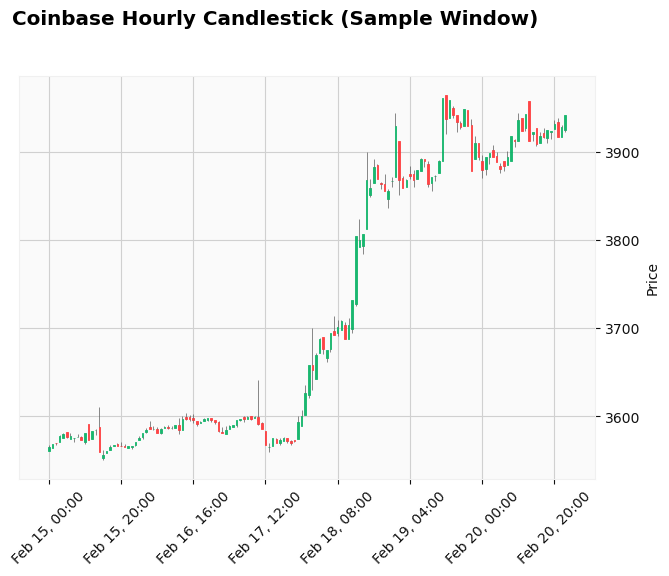

In [42]:
import mplfinance as mpf

ohlc_subset = ohlc_hourly.loc['2019-02-15':'2019-02-20']

fig,ax= mpf.plot(
    ohlc_subset,
    type='candle',
    style='yahoo',
    title=f'{best_exchange} Hourly Candlestick (Sample Window)',
    volume=False,
    returnfig= True  
)
fig.savefig('fig1_candlestick.png', dpi=300, bbox_inches='tight')
plt.show()

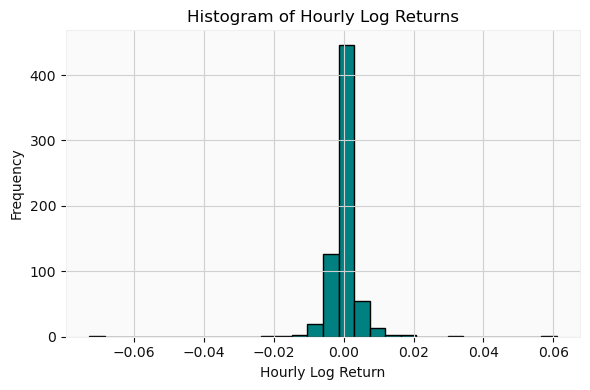

In [43]:
import numpy as np
import matplotlib.pyplot as plt

hourly_close = ohlc_hourly['close']
hourly_log_ret = np.log(hourly_close / hourly_close.shift(1))

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(hourly_log_ret.dropna(), bins=30, edgecolor='black', color='teal')
plt.title('Histogram of Hourly Log Returns')
plt.xlabel('Hourly Log Return')
plt.ylabel('Frequency')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('hist_hourly_log_returns.png', dpi=300, bbox_inches='tight')
plt.show()

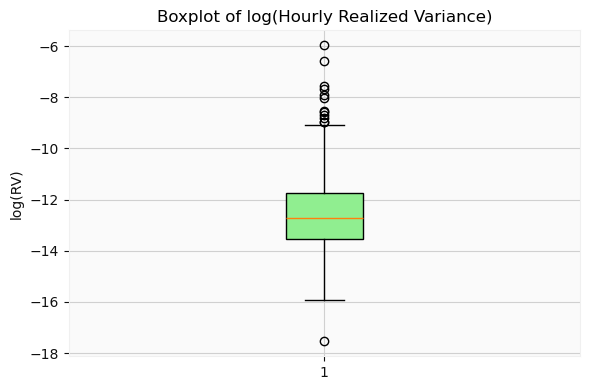

In [44]:
#plot box plot
plt.figure(figsize=(6,4))
plt.boxplot(
    np.log(hourly_rvar.dropna()),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen')
)
plt.title('Boxplot of log(Hourly Realized Variance)')
plt.ylabel('log(RV)')
plt.tight_layout()
plt.savefig('fig3_boxplot_log_hourly_rv.png', dpi=300, bbox_inches='tight')
plt.show()

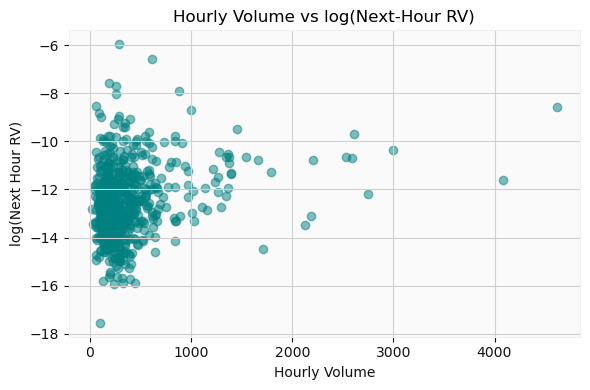

In [45]:
plt.figure(figsize=(6,4))
plt.scatter(
    hourly_data['Volume_lag'],
    np.log(hourly_data['RV_next']),
    color='teal',
    alpha=0.5
)
plt.title('Hourly Volume vs log(Next-Hour RV)')
plt.xlabel('Hourly Volume')
plt.ylabel('log(Next Hour RV)')
plt.tight_layout()
plt.savefig('fig4_volume_vs_next_hour_rv.png', dpi=300, bbox_inches='tight')
plt.show()

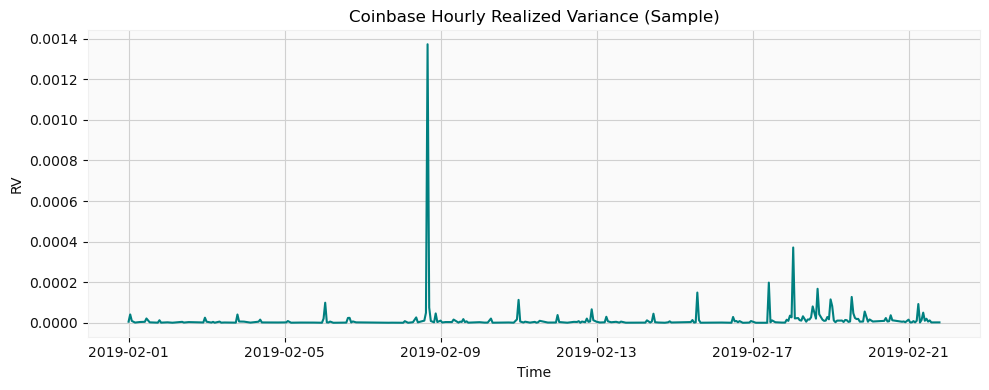

In [46]:
sample_rv = hourly_rvar.iloc[:500]

plt.figure(figsize=(10,4))
plt.plot(sample_rv.index, sample_rv.values, color='teal')
plt.title(f'{best_exchange} Hourly Realized Variance (Sample)')
plt.xlabel('Time')
plt.ylabel('RV')
plt.tight_layout()
plt.savefig('fig5_hourly_rv_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()